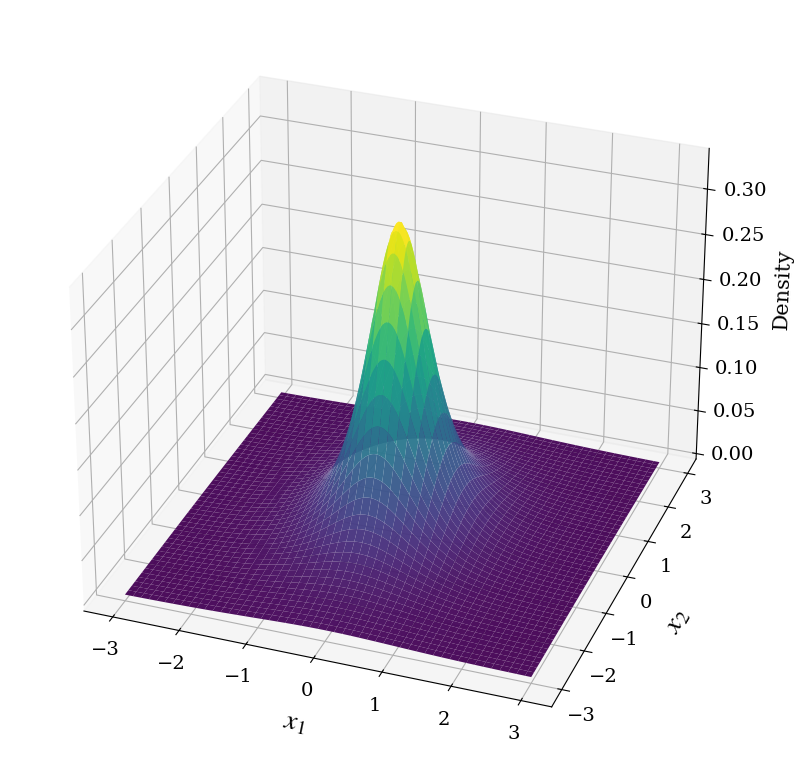

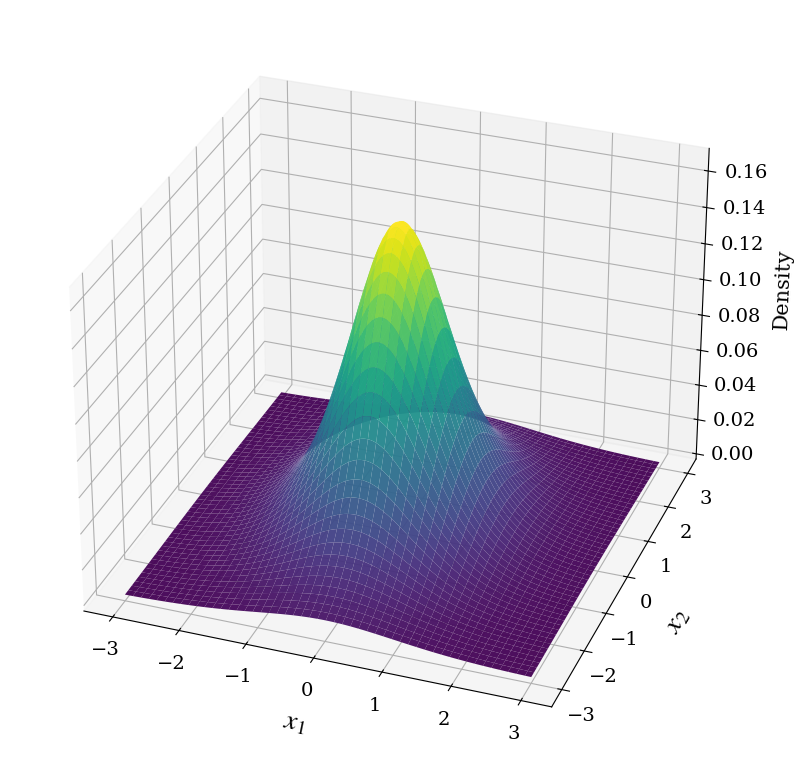

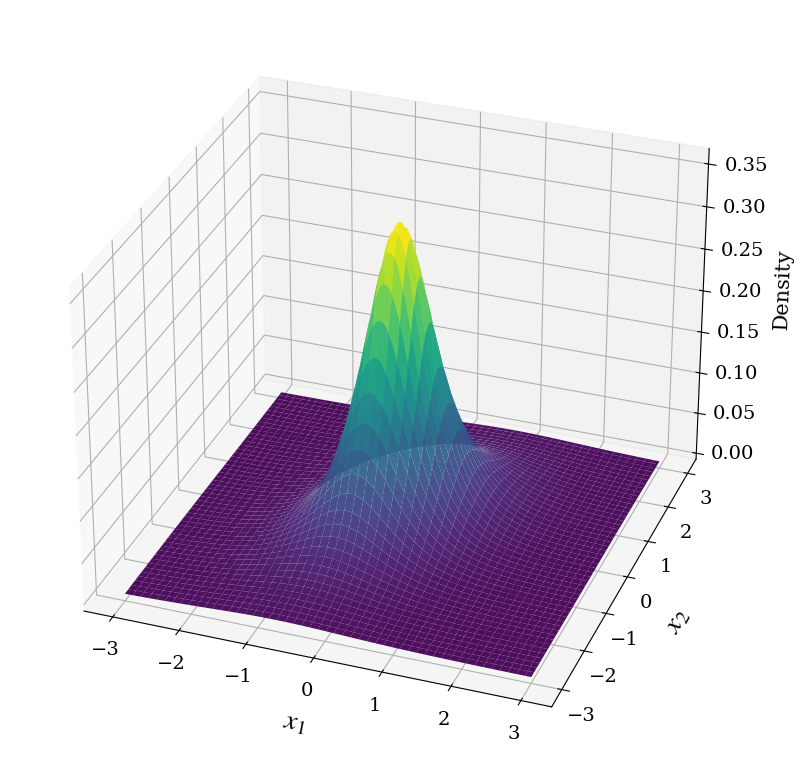

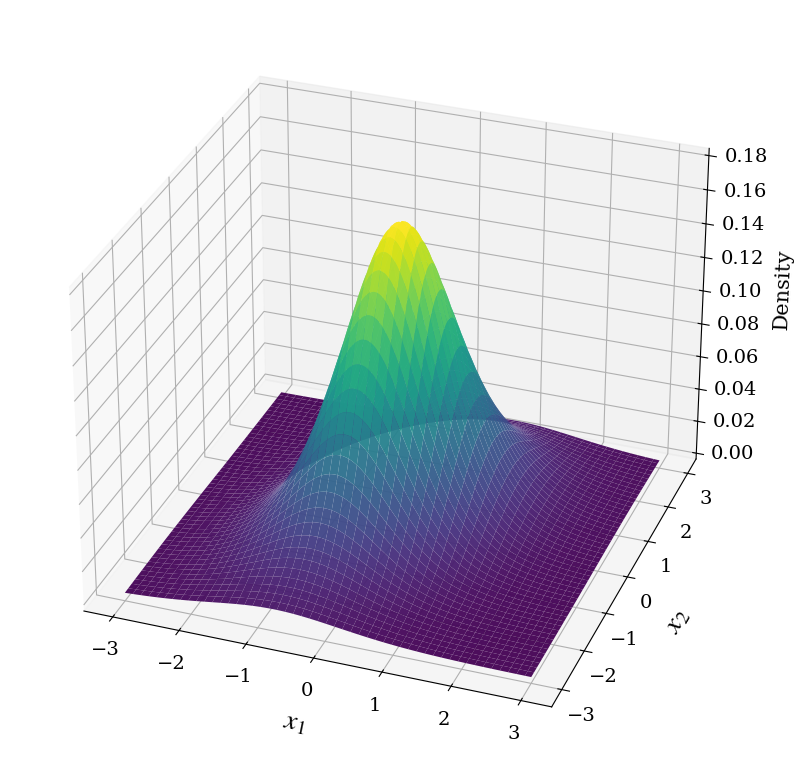

In [1]:
#=====================================================================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy.special import gamma, kv

# ===========================
# 1. 参数设置
# ===========================
d = 2  # 维度
lam = 0.5  # lambda 参数
mu = np.array([0.0, 0.0])  # 位置向量 mu

# 协方差矩阵 Sigma (必须是对称正定矩阵)
Sigma = np.array([[1.0, 0.0],
                  [0.0, 2.0]])

# ===========================
# 2. 定义二维密度函数
# ===========================
def density(X, Y, mu, Sigma, lam, d=2):
    # 计算协方差矩阵的行列式和逆矩阵
    det_Sigma = np.linalg.det(Sigma)
    inv_Sigma = np.linalg.inv(Sigma)

    # 向量化计算二次型 (x - mu)^T * Sigma^-1 * (x - mu)
    dx = X - mu[0]
    dy = Y - mu[1]
    
    # 展开二次型以支持 meshgrid 的二维数组计算
    Q = (inv_Sigma[0, 0] * dx**2 + 
         (inv_Sigma[0, 1] + inv_Sigma[1, 0]) * dx * dy + 
         inv_Sigma[1, 1] * dy**2)

    # 计算分布的归一化常数项
    coef_num = np.exp(lam) * np.sqrt(lam) * kv((d + 1) / 2, np.sqrt((Q + lam) * lam))
    coef_den = 2**((d - 1) / 2) * np.pi**((d + 1) / 2) * np.sqrt(det_Sigma)
    coef = coef_num / coef_den

    # 计算核心指数项
    core = (Q / lam + 1)**((d + 1) / 4)

    return coef / core

# =========================
# 3. 构造网格
# =========================
# 为正态-伽马分布选择对称的观测区间
x = np.linspace(-3, 3, 200)
y = np.linspace(-3, 3, 200)
X, Y = np.meshgrid(x, y)
Z = density(X, Y, mu, Sigma, lam, d)

# =========================
# 4. 绘图 (应用锁定的视觉风格)
# =========================
plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "stix",
    "font.size": 14
})

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# 曲面图
surf = ax.plot_surface(
    X, Y, Z,
    cmap=cm.viridis,
    edgecolor='none',
    antialiased=True,
    linewidth=0,
    alpha=0.95
)

# 坐标标签
ax.set_xlabel(r"$x_1$", labelpad=10, fontsize = 20)
ax.set_ylabel(r"$x_2$", labelpad=10, fontsize = 20)
ax.set_zlabel("Density", labelpad=18, fontsize = 15)
ax.tick_params(axis='z', pad=10)

# 在 figure 级别使用 text 添加标签（使用相对坐标 0-1）
fig.text(0.9, 0.5, ' ', 
         ha='center', va='center', 
         rotation=90, 
         fontsize=14,
         fontfamily='serif')

# 锁定视角
ax.view_init(elev=30, azim=-70)

plt.tight_layout()
plt.savefig('plot13', dpi=800, bbox_inches='tight', pad_inches=0.1)
plt.show()

#=====================================================================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy.special import gamma, kv

# ===========================
# 1. 参数设置
# ===========================
d = 2  # 维度
lam = 2.0  # lambda 参数
mu = np.array([0.0, 0.0])  # 位置向量 mu

# 协方差矩阵 Sigma (必须是对称正定矩阵)
Sigma = np.array([[1.0, 0.0],
                  [0.0, 2.0]])

# ===========================
# 2. 定义二维密度函数
# ===========================
def density(X, Y, mu, Sigma, lam, d=2):
    # 计算协方差矩阵的行列式和逆矩阵
    det_Sigma = np.linalg.det(Sigma)
    inv_Sigma = np.linalg.inv(Sigma)

    # 向量化计算二次型 (x - mu)^T * Sigma^-1 * (x - mu)
    dx = X - mu[0]
    dy = Y - mu[1]
    
    # 展开二次型以支持 meshgrid 的二维数组计算
    Q = (inv_Sigma[0, 0] * dx**2 + 
         (inv_Sigma[0, 1] + inv_Sigma[1, 0]) * dx * dy + 
         inv_Sigma[1, 1] * dy**2)

    # 计算分布的归一化常数项
    coef_num = np.exp(lam) * np.sqrt(lam) * kv((d + 1) / 2, np.sqrt((Q + lam) * lam))
    coef_den = 2**((d - 1) / 2) * np.pi**((d + 1) / 2) * np.sqrt(det_Sigma)
    coef = coef_num / coef_den

    # 计算核心指数项
    core = (Q / lam + 1)**((d + 1) / 4)

    return coef / core

# =========================
# 3. 构造网格
# =========================
# 为正态-伽马分布选择对称的观测区间
x = np.linspace(-3, 3, 200)
y = np.linspace(-3, 3, 200)
X, Y = np.meshgrid(x, y)
Z = density(X, Y, mu, Sigma, lam, d)

# =========================
# 4. 绘图 (应用锁定的视觉风格)
# =========================
plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "stix",
    "font.size": 14
})

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# 曲面图
surf = ax.plot_surface(
    X, Y, Z,
    cmap=cm.viridis,
    edgecolor='none',
    antialiased=True,
    linewidth=0,
    alpha=0.95
)

# 坐标标签
ax.set_xlabel(r"$x_1$", labelpad=10, fontsize = 20)
ax.set_ylabel(r"$x_2$", labelpad=10, fontsize = 20)
ax.set_zlabel("Density", labelpad=18, fontsize = 15)
ax.tick_params(axis='z', pad=10)

# 在 figure 级别使用 text 添加标签（使用相对坐标 0-1）
fig.text(0.9, 0.5, ' ', 
         ha='center', va='center', 
         rotation=90, 
         fontsize=14,
         fontfamily='serif')

# 锁定视角
ax.view_init(elev=30, azim=-70)

plt.tight_layout()
plt.savefig('plot14', dpi=800, bbox_inches='tight', pad_inches=0.1)
plt.show()

#=====================================================================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy.special import gamma, kv

# ===========================
# 1. 参数设置
# ===========================
d = 2  # 维度
lam = 0.5  # lambda 参数
mu = np.array([0.0, -0.0])  # 位置向量 mu

# 协方差矩阵 Sigma (必须是对称正定矩阵)
Sigma = np.array([[1.0, 0.5],
                  [0.5, 2.0]])

# ===========================
# 2. 定义二维密度函数
# ===========================
def density(X, Y, mu, Sigma, lam, d=2):
    # 计算协方差矩阵的行列式和逆矩阵
    det_Sigma = np.linalg.det(Sigma)
    inv_Sigma = np.linalg.inv(Sigma)

    # 向量化计算二次型 (x - mu)^T * Sigma^-1 * (x - mu)
    dx = X - mu[0]
    dy = Y - mu[1]
    
    # 展开二次型以支持 meshgrid 的二维数组计算
    Q = (inv_Sigma[0, 0] * dx**2 + 
         (inv_Sigma[0, 1] + inv_Sigma[1, 0]) * dx * dy + 
         inv_Sigma[1, 1] * dy**2)

    # 计算分布的归一化常数项
    coef_num = np.exp(lam) * np.sqrt(lam) * kv((d + 1) / 2, np.sqrt((Q + lam) * lam))
    coef_den = 2**((d - 1) / 2) * np.pi**((d + 1) / 2) * np.sqrt(det_Sigma)
    coef = coef_num / coef_den

    # 计算核心指数项
    core = (Q / lam + 1)**((d + 1) / 4)

    return coef / core

# =========================
# 3. 构造网格
# =========================
# 为正态-伽马分布选择对称的观测区间
x = np.linspace(-3, 3, 200)
y = np.linspace(-3, 3, 200)
X, Y = np.meshgrid(x, y)
Z = density(X, Y, mu, Sigma, lam, d)

# =========================
# 4. 绘图 (应用锁定的视觉风格)
# =========================
plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "stix",
    "font.size": 14
})

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# 曲面图
surf = ax.plot_surface(
    X, Y, Z,
    cmap=cm.viridis,
    edgecolor='none',
    antialiased=True,
    linewidth=0,
    alpha=0.95
)

# 坐标标签
ax.set_xlabel(r"$x_1$", labelpad=10, fontsize = 20)
ax.set_ylabel(r"$x_2$", labelpad=10, fontsize = 20)
ax.set_zlabel("Density", labelpad=18, fontsize = 15)
ax.tick_params(axis='z', pad=10)

# 在 figure 级别使用 text 添加标签（使用相对坐标 0-1）
fig.text(0.9, 0.5, ' ', 
         ha='center', va='center', 
         rotation=90, 
         fontsize=14,
         fontfamily='serif')

# 锁定视角
ax.view_init(elev=30, azim=-70)

plt.tight_layout()
plt.savefig('plot15', dpi=800, bbox_inches='tight', pad_inches=0.1)
plt.show()

#=====================================================================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy.special import gamma, kv

# ===========================
# 1. 参数设置
# ===========================
d = 2  # 维度
lam = 2.0  # lambda 参数
mu = np.array([0.0, 0.0])  # 位置向量 mu

# 协方差矩阵 Sigma (必须是对称正定矩阵)
Sigma = np.array([[1.0, 0.5],
                  [0.5, 2.0]])

# ===========================
# 2. 定义二维密度函数
# ===========================
def density(X, Y, mu, Sigma, lam, d=2):
    # 计算协方差矩阵的行列式和逆矩阵
    det_Sigma = np.linalg.det(Sigma)
    inv_Sigma = np.linalg.inv(Sigma)

    # 向量化计算二次型 (x - mu)^T * Sigma^-1 * (x - mu)
    dx = X - mu[0]
    dy = Y - mu[1]
    
    # 展开二次型以支持 meshgrid 的二维数组计算
    Q = (inv_Sigma[0, 0] * dx**2 + 
         (inv_Sigma[0, 1] + inv_Sigma[1, 0]) * dx * dy + 
         inv_Sigma[1, 1] * dy**2)

    # 计算分布的归一化常数项
    coef_num = np.exp(lam) * np.sqrt(lam) * kv((d + 1) / 2, np.sqrt((Q + lam) * lam))
    coef_den = 2**((d - 1) / 2) * np.pi**((d + 1) / 2) * np.sqrt(det_Sigma)
    coef = coef_num / coef_den

    # 计算核心指数项
    core = (Q / lam + 1)**((d + 1) / 4)

    return coef / core

# =========================
# 3. 构造网格
# =========================
# 为正态-伽马分布选择对称的观测区间
x = np.linspace(-3, 3, 200)
y = np.linspace(-3, 3, 200)
X, Y = np.meshgrid(x, y)
Z = density(X, Y, mu, Sigma, lam, d)

# =========================
# 4. 绘图 (应用锁定的视觉风格)
# =========================
plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "stix",
    "font.size": 14
})

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# 曲面图
surf = ax.plot_surface(
    X, Y, Z,
    cmap=cm.viridis,
    edgecolor='none',
    antialiased=True,
    linewidth=0,
    alpha=0.95
)

# 坐标标签
ax.set_xlabel(r"$x_1$", labelpad=10, fontsize = 20)
ax.set_ylabel(r"$x_2$", labelpad=10, fontsize = 20)
ax.set_zlabel("Density", labelpad=18, fontsize = 15)
ax.tick_params(axis='z', pad=10)

# 在 figure 级别使用 text 添加标签（使用相对坐标 0-1）
fig.text(0.9, 0.5, ' ', 
         ha='center', va='center', 
         rotation=90, 
         fontsize=14,
         fontfamily='serif')

# 锁定视角
ax.view_init(elev=30, azim=-70)

plt.tight_layout()
plt.savefig('plot16', dpi=800, bbox_inches='tight', pad_inches=0.1)
plt.show()